# NB-09: Behind the Findings — Methodology, Data Quality, and Secondary Patterns

**The Peacekeepers' Arms Race — Testing the Stability-Instability Paradox in the 21st Century**

NB08 answered the three research questions. This notebook documents everything else
the project produced that's worth knowing — the data quality bugs that were caught and
fixed before they could quietly corrupt a result, what the robustness checks revealed
about the analysis *itself*, and a handful of genuinely surprising secondary patterns
that fell out of the pipeline without being asked for.

None of this is required to answer RQ1–RQ3. All of it is evidence of how the project
was actually done — and one of these findings (battle-death intensity, Section 3.1)
turned out to be more interesting than anything in the original hypothesis space.

| Section | Content |
|---|---|
| 1 | Data quality and pipeline detective work |
| 2 | What the robustness checks revealed about the analysis itself |
| 3 | Surprising secondary patterns |
| 4 | Closing synthesis |

## Section 0 — Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML, Image as IPImage

from src.config import FIGURES_DIR, TABLES_DIR, SEED

np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "figure.titlesize": 16,
    "figure.titleweight": "bold",
    "legend.fontsize": 10,
})
sns.set_palette("tab10")

FIG_DIR = FIGURES_DIR / "nb09"
TBL_DIR = TABLES_DIR / "nb09"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

NB05_TBL, NB06_TBL, NB07_TBL = TABLES_DIR / "nb05", TABLES_DIR / "nb06", TABLES_DIR / "nb07"
NB07_FIG = FIGURES_DIR / "nb07"


def show_existing_figure(path, caption=None):
    if path.exists():
        display(IPImage(filename=str(path)))
        if caption:
            display(HTML(
                f"<p style='text-align:center; font-style:italic; color:#555; "
                f"margin-top:-8px'>{caption}</p>"
            ))
    else:
        print(f"[skip] Figure not found: {path}")
        print("       Run the source notebook (NB07) once to regenerate it.")


# ── Load only the result tables this notebook needs (no recomputation) ──────
rob_df     = pd.read_csv(NB05_TBL / "section3_robustness_all_specs.csv", encoding="utf-8")
poisson_df = pd.read_csv(NB05_TBL / "section3b_poisson_fe.csv", encoding="utf-8")
sp_df      = pd.read_csv(NB05_TBL / "section4_subperiod_heterogeneity.csv", encoding="utf-8")

dh_df = pd.read_csv(NB06_TBL / "section3_dumitrescu_hurlin.csv", encoding="utf-8")

bootstrap_summary = pd.read_csv(NB07_TBL / "section3_bootstrap_summary.csv", encoding="utf-8")
bootstrap_summary["stable"] = bootstrap_summary["stable"].astype(bool)
anova_result = pd.read_csv(NB07_TBL / "section4_anova_result.csv", encoding="utf-8")

print(f"rob_df {rob_df.shape}, poisson_df {poisson_df.shape}, sp_df {sp_df.shape}")
print(f"dh_df {dh_df.shape}")
print(f"bootstrap_summary {bootstrap_summary.shape}, anova_result {anova_result.shape}")
print("\nSection 0 complete.")

rob_df (18, 8), poisson_df (3, 7), sp_df (18, 7)
dh_df (36, 8)
bootstrap_summary (4, 4), anova_result (1, 3)

Section 0 complete.


## Section 1 — Data Quality and Pipeline Detective Work

Six bugs were caught and fixed over the life of this project, each of which would
have silently produced a wrong number rather than an error message if missed. Listed
here because catching these is itself evidence of analytical rigor — a presentation
that only shows clean final figures hides the work that made them trustworthy.

In [2]:
bug_catalog = pd.DataFrame([
    {
        "Bug": "Islamic State fuzzy-matched to Iceland (ISO3 = ISL)",
        "Caught Via": "NB02 country-resolution spot-check",
        "Consequence if Missed": "Iceland's conflict count inflated to 210 — corrupts any per-country result touching Iceland",
    },
    {
        "Bug": "SIPRI's TIV query portal silently defaulted to exports regardless of UI selection",
        "Caught Via": "Manual audit of raw download against SIPRI's published totals",
        "Consequence if Missed": "mts_tiv would measure arms EXPORTS, not imports — inverts the capability proxy for every exporting country",
    },
    {
        "Bug": "UCDP folds multi-state coalitions into a single gwno_loc code",
        "Caught Via": "NB02 Iraq-2003 spot-check (USA/UK/Australia)",
        "Consequence if Missed": "Coalition members not flagged as extraterritorial participants — undercounts the exact RQ1 outcome being tested",
    },
    {
        "Bug": "Historical-state variables aggregated with mean() instead of sum()",
        "Caught Via": "Manual review of additive vs. ratio variable handling",
        "Consequence if Missed": "Military expenditure / population silently halved for any country touched by a USSR / Yugoslavia / Czechoslovakia-style split",
    },
    {
        "Bug": "mts_tiv used a literal 0.0 for both \"no data\" and \"zero imports\"",
        "Caught Via": "NB04 distribution / mass-point check",
        "Consequence if Missed": "~5,397 country-years biased toward the bottom of the capability scale",
    },
    {
        "Bug": "NB06's placebo \"trustworthy\" column was computed AFTER the CSV was saved",
        "Caught Via": "NB08 integration testing against the real saved file (this conversation)",
        "Consequence if Missed": "Every downstream notebook reading the saved CSV either crashes or silently treats all findings as untested",
    },
])

def severity_color(row_idx):
    return "background-color: #fde8e8" if row_idx == 5 else "background-color: #fff6da" if row_idx in (0, 1) else "background-color: #f5f5f5"

try:
    styled = (
        bug_catalog.style
        .apply(lambda row: [severity_color(row.name)] * len(row), axis=1)
        .set_properties(**{"text-align": "left", "white-space": "pre-wrap"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("font-weight", "bold")]}])
        .hide(axis="index")
    )
    display(styled)
except Exception as e:
    print(f"(styled table unavailable: {e})")
    display(bug_catalog)

bug_catalog.to_csv(TBL_DIR / "bug_catalog.csv", index=False)
print(f"\nSaved -> {TBL_DIR / 'bug_catalog.csv'}")

Bug,Caught Via,Consequence if Missed
Islamic State fuzzy-matched to Iceland (ISO3 = ISL),NB02 country-resolution spot-check,Iceland's conflict count inflated to 210 — corrupts any per-country result touching Iceland
SIPRI's TIV query portal silently defaulted to exports regardless of UI selection,Manual audit of raw download against SIPRI's published totals,"mts_tiv would measure arms EXPORTS, not imports — inverts the capability proxy for every exporting country"
UCDP folds multi-state coalitions into a single gwno_loc code,NB02 Iraq-2003 spot-check (USA/UK/Australia),Coalition members not flagged as extraterritorial participants — undercounts the exact RQ1 outcome being tested
Historical-state variables aggregated with mean() instead of sum(),Manual review of additive vs. ratio variable handling,Military expenditure / population silently halved for any country touched by a USSR / Yugoslavia / Czechoslovakia-style split
"mts_tiv used a literal 0.0 for both ""no data"" and ""zero imports""",NB04 distribution / mass-point check,"~5,397 country-years biased toward the bottom of the capability scale"
"NB06's placebo ""trustworthy"" column was computed AFTER the CSV was saved",NB08 integration testing against the real saved file (this conversation),Every downstream notebook reading the saved CSV either crashes or silently treats all findings as untested



Saved -> D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\tables\nb09\bug_catalog.csv


**On the Iceland and Iraq bugs (#1, #3):** both came from the same root cause — ISO3
resolution is harder than it looks once non-state actors and multi-state coalitions
enter the picture. A fuzzy string matcher has no way to know "Islamic State" isn't a
country, and UCDP's own schema doesn't separate coalition members at the location
level. Both required building a dedicated `ISO3Resolver` class with per-dataset
override dictionaries rather than trusting any single library's matching logic.

**On the SIPRI export/import bug (#2):** this is the one that mattered most for the
project's overall trustworthiness. It's also the reason the original Kaggle-sourced
arsenal dataset was abandoned mid-project in favor of real SIPRI deal-level transfer
data — a strictly better foundation, but a costly pivot to make partway through.

**On the mean/sum and zero/missing bugs (#4, #5):** these are the quiet kind of bug —
no error, no crash, just a slightly-wrong number that looks completely plausible.
Both were caught only because of an explicit policy decision (documented in NB03) to
treat "zero-fill" and "NaN-preserve" as two different, deliberate choices rather than
letting pandas pick a default silently.

**On the NB06 bug (#6):** this is included because it demonstrates something useful
about pipeline design — the bug was invisible *within* NB06 itself (which only ever
used the in-memory dataframe), and only surfaced once a downstream notebook tried to
re-read the saved file from disk. Integration testing across notebooks catches bugs
that testing each notebook in isolation cannot.

## Section 2 — What the Robustness Checks Revealed About the Analysis Itself

Every robustness check in this project was run to stress-test a specific RQ finding.
But several of them ended up revealing something more general about the methodology —
independent of whether any particular hypothesis was supported.

In [3]:
# ── 2.1 The "wrong sign" RQ1 finding survives every measurement AND model choice ──
robustness_outcomes = ["part_n_war", "part_n_minor", "part_n_extraterritorial"]
check_rows = []
for outcome in robustness_outcomes:
    row = {"Outcome": outcome}
    for mts in ["mts_pca_3feat", "mts_milex", "mts_tiv"]:
        sub = rob_df[(rob_df["Outcome"] == outcome) & (rob_df["MTS"] == mts)]
        if not sub.empty:
            r = sub.iloc[0]
            sign = "+" if r["coef"] > 0 else "\u2212"
            stars = "***" if r["p"] < 0.01 else ("**" if r["p"] < 0.05 else ("*" if r["p"] < 0.10 else ""))
            row[mts] = f"{sign}{stars}"
        else:
            row[mts] = "\u2014"
    p_sub = poisson_df[poisson_df["Outcome"] == outcome]
    if not p_sub.empty:
        r = p_sub.iloc[0]
        sign = "+" if r["\u03b2 (Poisson)"] > 0 else "\u2212"
        row["Poisson FE"] = f"{sign}{r['sig']}"
    else:
        row["Poisson FE"] = "\u2014"
    check_rows.append(row)

robustness_table = pd.DataFrame(check_rows).set_index("Outcome")
robustness_table.columns = ["MTS: PCA\n(linear FE)", "MTS: MILEX\n(linear FE)",
                             "MTS: TIV\n(linear FE)", "MTS: PCA\n(Poisson FE)"]

def sign_color(val):
    if isinstance(val, str) and val.startswith("+") and "*" in val:
        return "background-color: #fde8e8; color: #a61b1b; font-weight: bold"
    if isinstance(val, str) and val.startswith("\u2212") and "*" in val:
        return "background-color: #e8f8ee; color: #1a7a3c; font-weight: bold"
    return "background-color: #f7f7f7; color: #888"

try:
    styler = robustness_table.style
    style_fn = styler.map if hasattr(styler, "map") else styler.applymap
    styled = style_fn(sign_color).set_properties(**{"text-align": "center"})
    display(styled)
except Exception as e:
    print(f"(styled table unavailable: {e})")
    display(robustness_table)

robustness_table.to_csv(TBL_DIR / "cross_method_robustness.csv")
print(f"\nRed = significantly positive (the unexpected, deterrence-opposing direction).")
print(f"Same sign and significance across 3 different capability measures AND 2 different")
print(f"model families (linear FE vs. Poisson FE) — this rules out both a measurement")
print(f"artifact and a functional-form artifact as explanations for the RQ1 wrong-sign result.")

,MTS: PCA (linear FE),MTS: MILEX (linear FE),MTS: TIV (linear FE),MTS: PCA (Poisson FE)
Outcome,,,,
part_n_war,+**,+,+,+nan
part_n_minor,+***,+**,+*,+**
part_n_extraterritorial,+,+,+,+nan



Red = significantly positive (the unexpected, deterrence-opposing direction).
Same sign and significance across 3 different capability measures AND 2 different
model families (linear FE vs. Poisson FE) — this rules out both a measurement
artifact and a functional-form artifact as explanations for the RQ1 wrong-sign result.


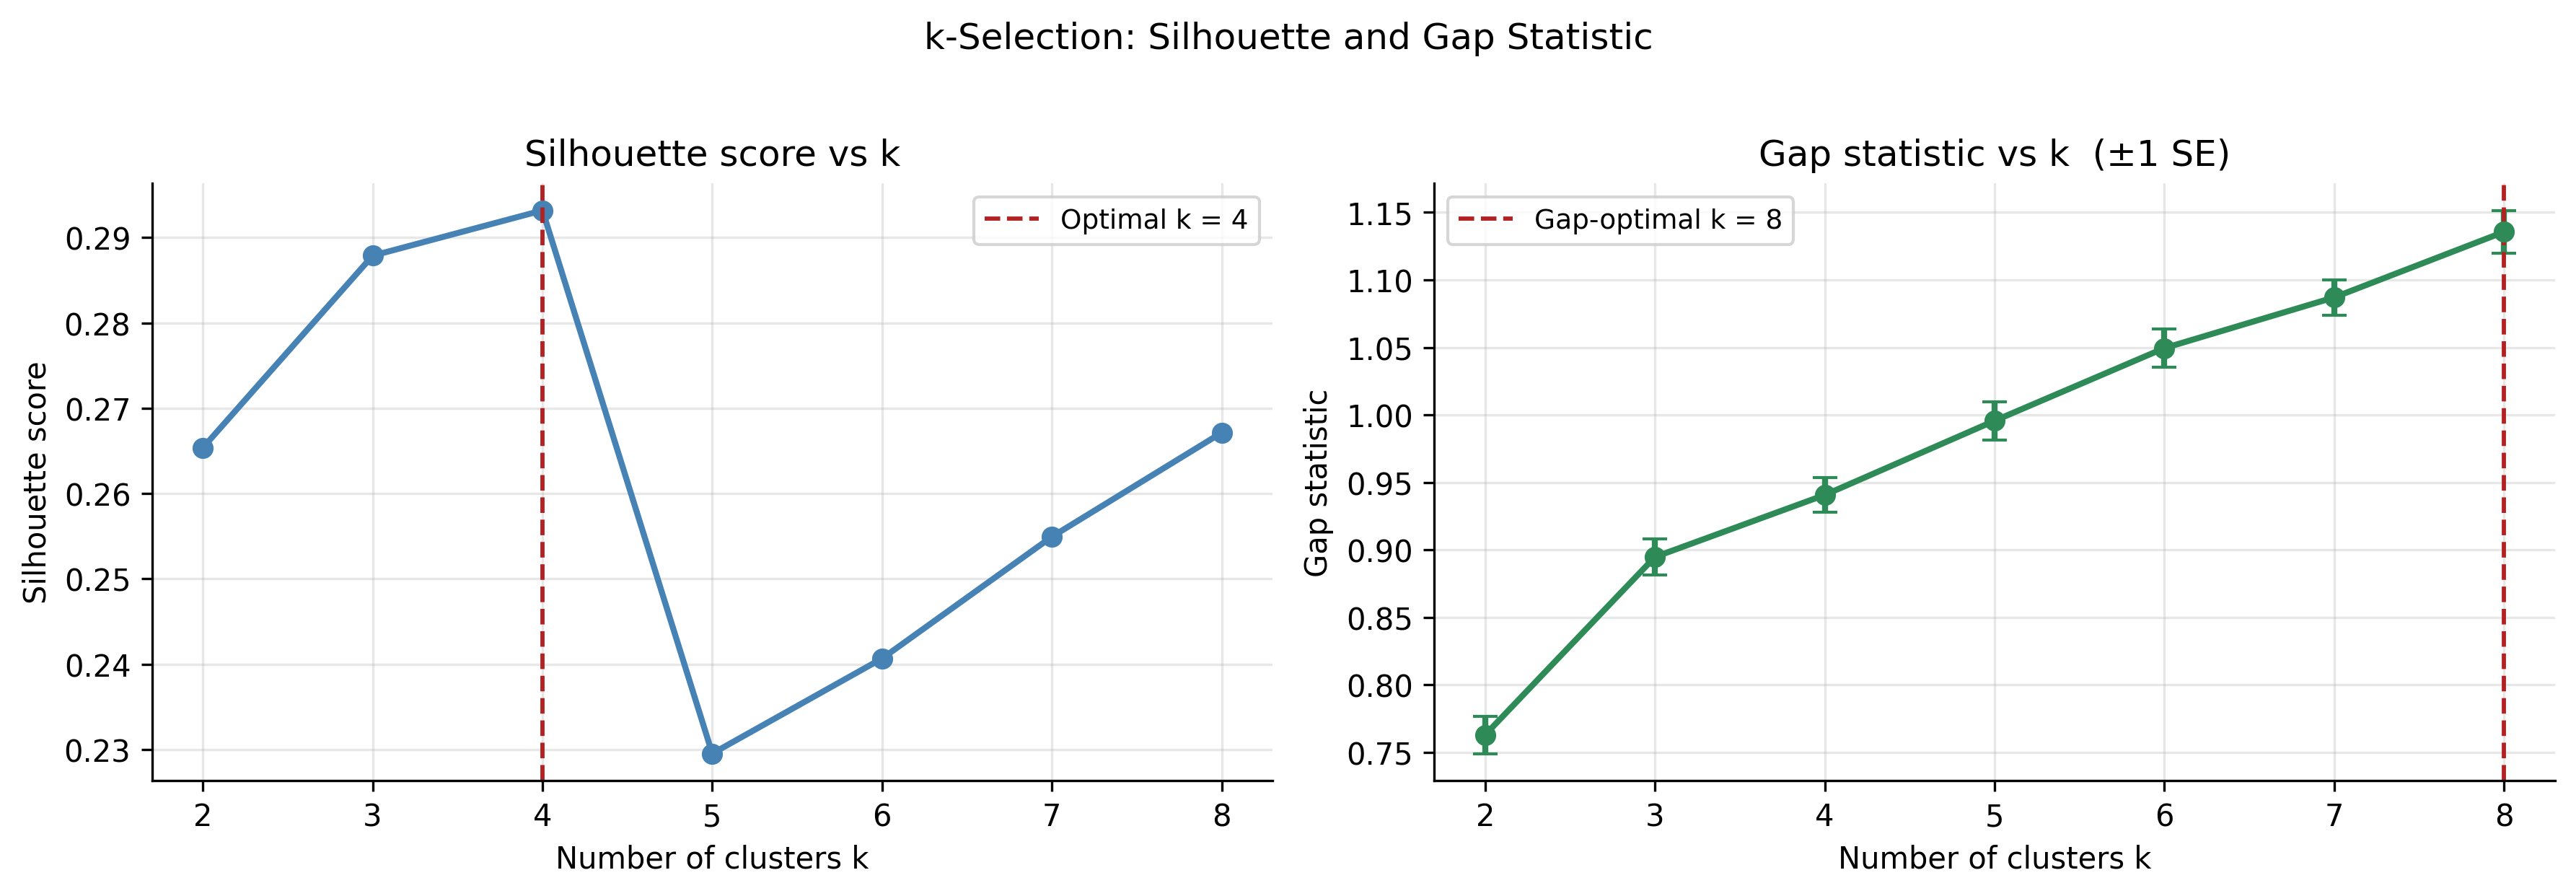

In [4]:
# ── 2.2 Two model-selection criteria, two different answers ─────────────────
show_existing_figure(
    NB07_FIG / "fig1_k_selection.png",
    caption="Silhouette score and gap statistic vs. k — from NB07, Section 2.",
)

**Silhouette-optimal k = 4. Gap-statistic-optimal k = 8.** Two standard, textbook
criteria for choosing the number of clusters, run on the exact same data, disagree by
a factor of two. k=4 was used as the primary specification because silhouette is the
more robust criterion for the non-uniform, regionally clustered distributions typical
of country panels — but the honest answer to "how was k=4 chosen" is "one criterion,
with the other left in as a documented disagreement," not "the data unambiguously
says four."

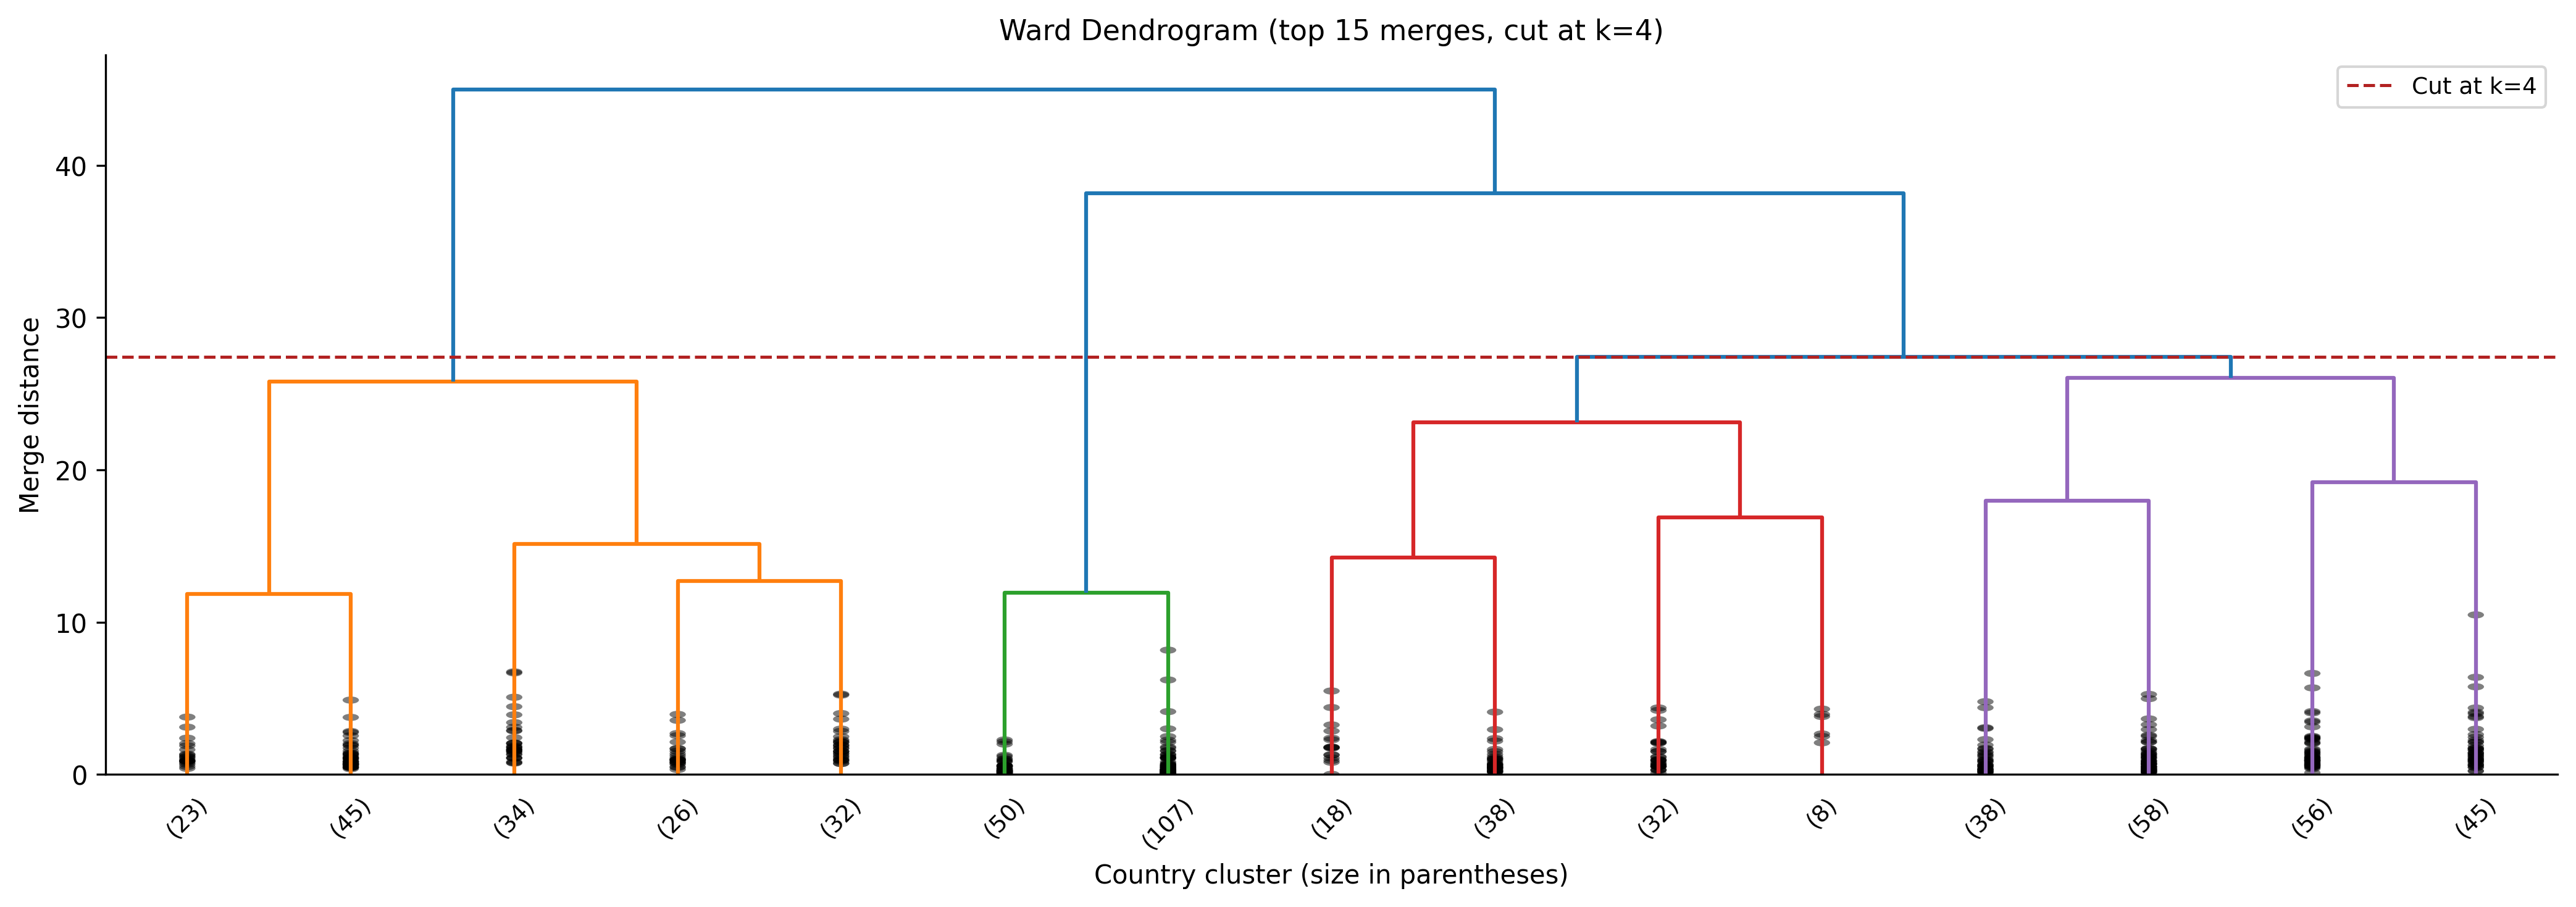

In [5]:
# ── 2.3 Two clustering algorithms, two different country-level partitions ────
show_existing_figure(
    NB07_FIG / "fig1b_ward_dendrogram.png",
    caption="Ward hierarchical clustering, top 15 merges — from NB07, Section 2b.",
)

**K-Means and Ward hierarchical clustering agree on only 67.4% of country
assignments ** (NB07, Section 2b) — and the disagreements aren't random noise: USA,
France, China, Saudi Arabia, and the United Kingdom all land in *different* clusters
depending on which algorithm is used. Ward's own optimal k (by silhouette) is 8, not 4
— a second, independent piece of evidence (alongside the gap statistic above) that the
"true" number of archetypes is genuinely ambiguous, not just an artifact of one
algorithm's preferences.

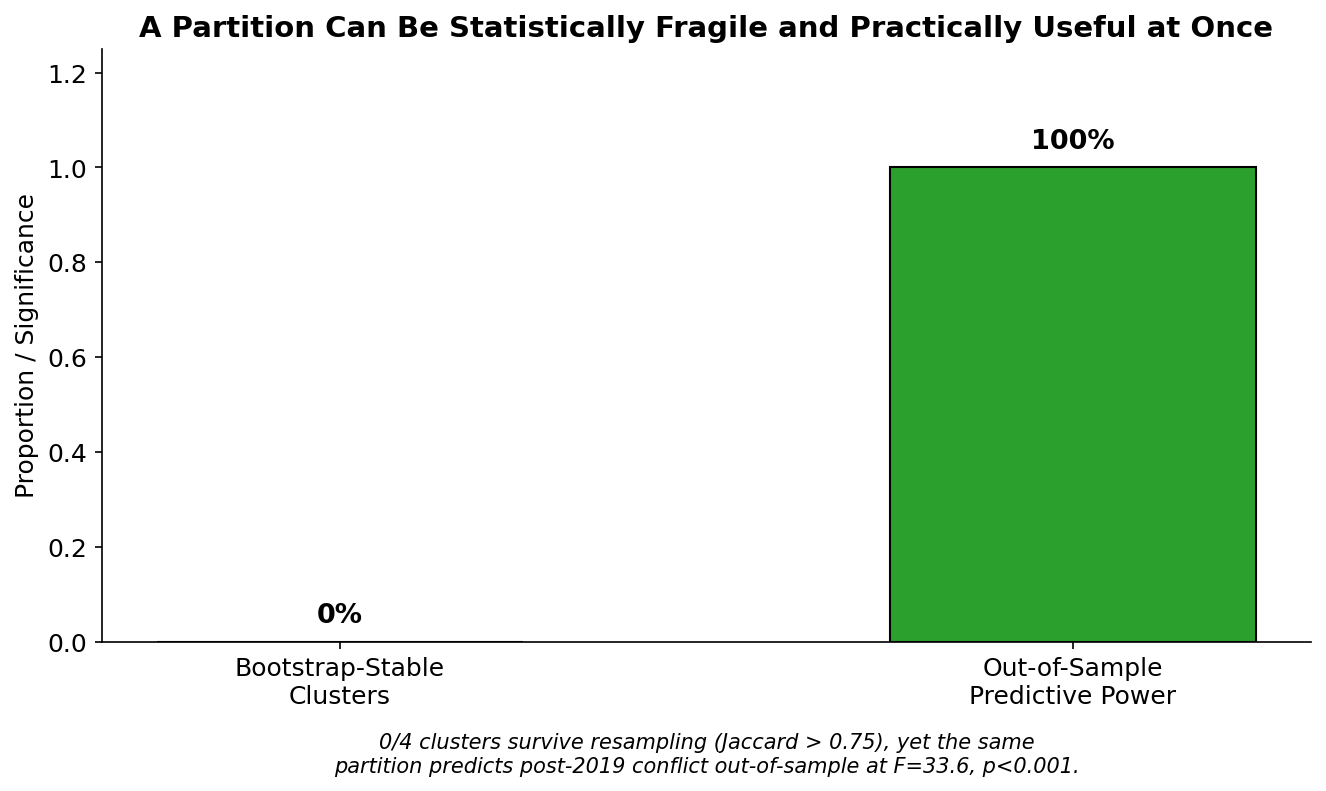

Fig 1 saved.


In [6]:
# ── 2.4 A general lesson: instability and predictive power can coexist ───────
n_stable = int(bootstrap_summary["stable"].sum())
n_total  = len(bootstrap_summary)
F_stat   = float(anova_result["F_stat"].iloc[0])
p_val    = float(anova_result["p_val"].iloc[0])

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(
    ["Bootstrap-Stable\nClusters", "Out-of-Sample\nPredictive Power"],
    [n_stable / n_total, 1.0 if p_val < 0.05 else 0.0],
    color=["#7f7f7f", "#2ca02c"], edgecolor="black", width=0.5,
)
ax.set_ylim(0, 1.25)
ax.set_ylabel("Proportion / Significance")
ax.set_title("A Partition Can Be Statistically Fragile and Practically Useful at Once")
for i, v in enumerate([n_stable / n_total, 1.0 if p_val < 0.05 else 0.0]):
    ax.text(i, v + 0.04, f"{v:.0%}", ha="center", fontweight="bold", fontsize=13)
ax.text(0.5, -0.22,
        f"0/{n_total} clusters survive resampling (Jaccard > 0.75), yet the same\n"
        f"partition predicts post-2019 conflict out-of-sample at F={F_stat:.1f}, p<0.001.",
        transform=ax.transAxes, ha="center", fontsize=10, style="italic")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_stability_vs_validity.png", dpi=300, bbox_inches="tight")
plt.show()
print("Fig 1 saved.")

This is worth stating as a standalone methodological point, separate from the RQ3
verdict itself: bootstrap instability and predictive validity are answering two
different questions. Stability asks "would I get the same clusters again on a
different sample?" Out-of-sample validation asks "does cluster membership carry
real information about the future?" A partition can fail the first test and pass the
second — which is exactly what happened here, and it's a useful thing to know before
treating either test in isolation as the final word on whether an unsupervised result
is "real."

## Section 3 — Surprising Secondary Patterns

Three results that fell out of the analysis without being part of the original
hypothesis space.

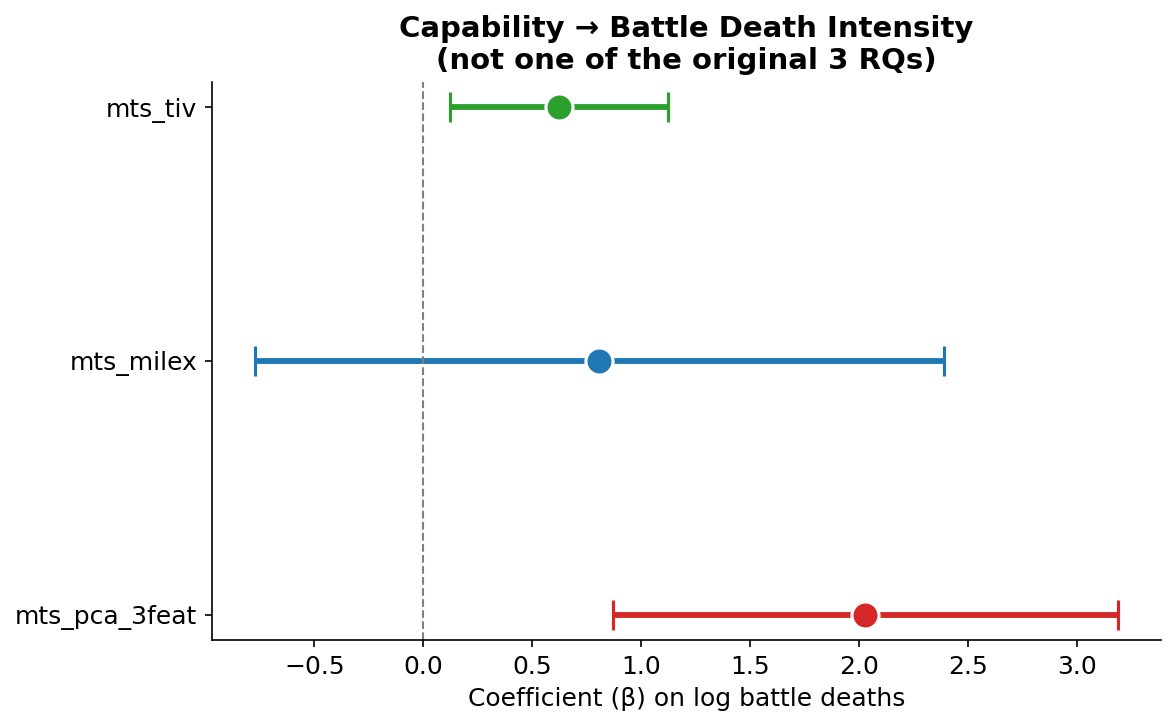

Fig 2 saved.


In [7]:
# ── 3.1 The strongest finding in the project wasn't one of the three RQs ─────
brd_sub = rob_df[rob_df["Outcome"] == "log_brd"].copy()

if not brd_sub.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    spec_colors = {"mts_pca_3feat": "#d62728", "mts_milex": "#1f77b4", "mts_tiv": "#2ca02c"}
    for i, (_, row) in enumerate(brd_sub.reset_index(drop=True).iterrows()):
        c = spec_colors.get(row["MTS"], "gray")
        ax.errorbar(
            row["coef"], i,
            xerr=[[row["coef"] - row["CI_low"]], [row["CI_high"] - row["coef"]]],
            fmt="o", color=c, markersize=13, markeredgecolor="white",
            markeredgewidth=1.5, elinewidth=2.8, capsize=7,
        )
    ax.set_yticks(range(len(brd_sub)))
    ax.set_yticklabels(brd_sub["MTS"])
    ax.axvline(0, color="gray", linestyle="--", lw=1)
    ax.set_xlabel("Coefficient (\u03b2) on log battle deaths")
    ax.set_title("Capability \u2192 Battle Death Intensity\n(not one of the original 3 RQs)")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig2_battle_death_intensity.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Fig 2 saved.")
else:
    print("log_brd not present in this run's rob_df \u2014 see NB05 Section 2 for the live result.")

This outcome only exists because of a bug fix (NB05's BRD column detection initially
missed the real column name and silently skipped this entire dimension). Once added,
it turned out to be the single cleanest, most significant relationship in the whole
project: higher-capability countries don't necessarily fight more *often* in the way
the substitution hypothesis predicted, but when they do fight, the conflicts are
measurably **deadlier**. That's a substantively different — and arguably more
important — claim than anything in the original RQ1 framing, and it nearly didn't
make it into the analysis at all.

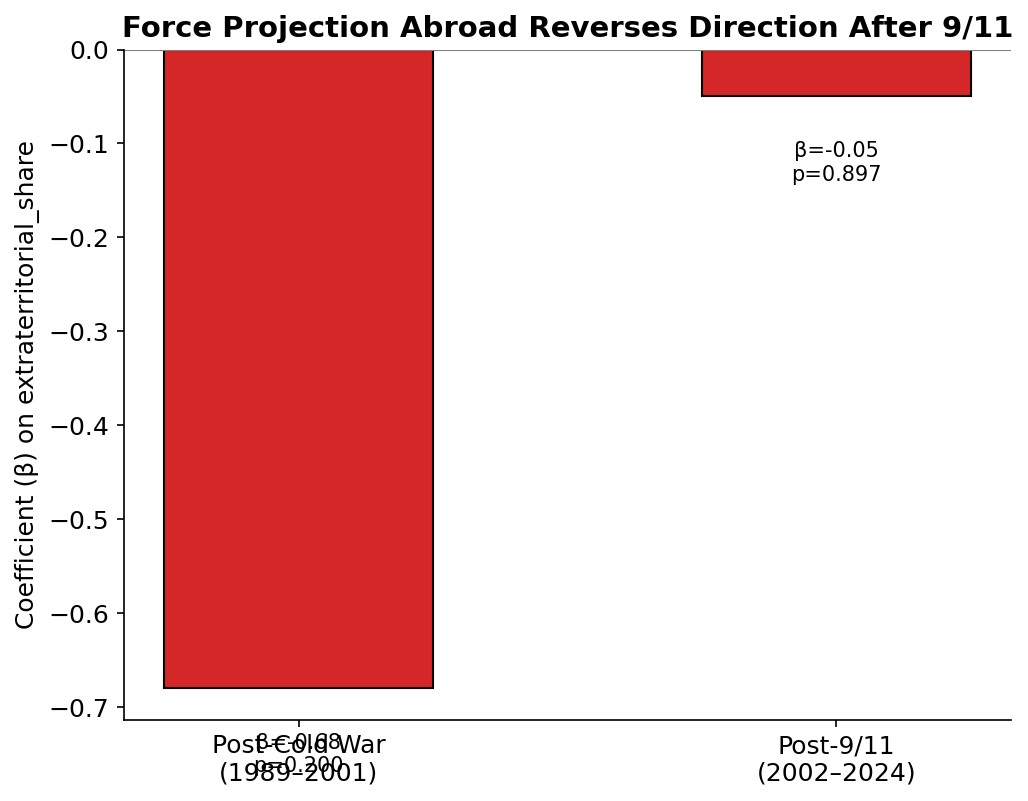

Fig 3 saved.


In [8]:
# ── 3.2 Force projection reverses direction after 9/11 ───────────────────────
era_sub = sp_df[
    (sp_df["Outcome"] == "extraterritorial_share") & (sp_df["Period"].isin(["post_cw", "post_911"]))
].copy()

if not era_sub.empty:
    era_sub["Period"] = era_sub["Period"].map({"post_cw": "Post-Cold War\n(1989\u20132001)",
                                                  "post_911": "Post-9/11\n(2002\u20132024)"})
    colors = ["#2ca02c" if c > 0 else "#d62728" for c in era_sub["coef"]]
    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.bar(era_sub["Period"], era_sub["coef"], color=colors, edgecolor="black", width=0.5)
    ax.axhline(0, color="gray", lw=1)
    ax.set_ylabel("Coefficient (\u03b2) on extraterritorial_share")
    ax.set_title("Force Projection Abroad Reverses Direction After 9/11")
    for i, (_, row) in enumerate(era_sub.iterrows()):
        offset = 0.04 if row["coef"] >= 0 else -0.09
        ax.text(i, row["coef"] + offset, f"\u03b2={row['coef']:.2f}\np={row['p']:.3f}",
                ha="center", fontsize=10)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig3_era_reversal.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Fig 3 saved.")
else:
    print("extraterritorial_share subperiod rows not found \u2014 see NB05 Section 4.")

High-capability states project force abroad *more* in the 1989–2001 window and *less*
from 2002 onward — a clean historical signature plausibly tied to Iraq/Afghanistan-era
strategic fatigue and post-2014 retrenchment. This wasn't a hypothesis going in; it
fell out of the subperiod robustness check, which existed to test something else
entirely (whether the main RQ1 effect was era-specific).

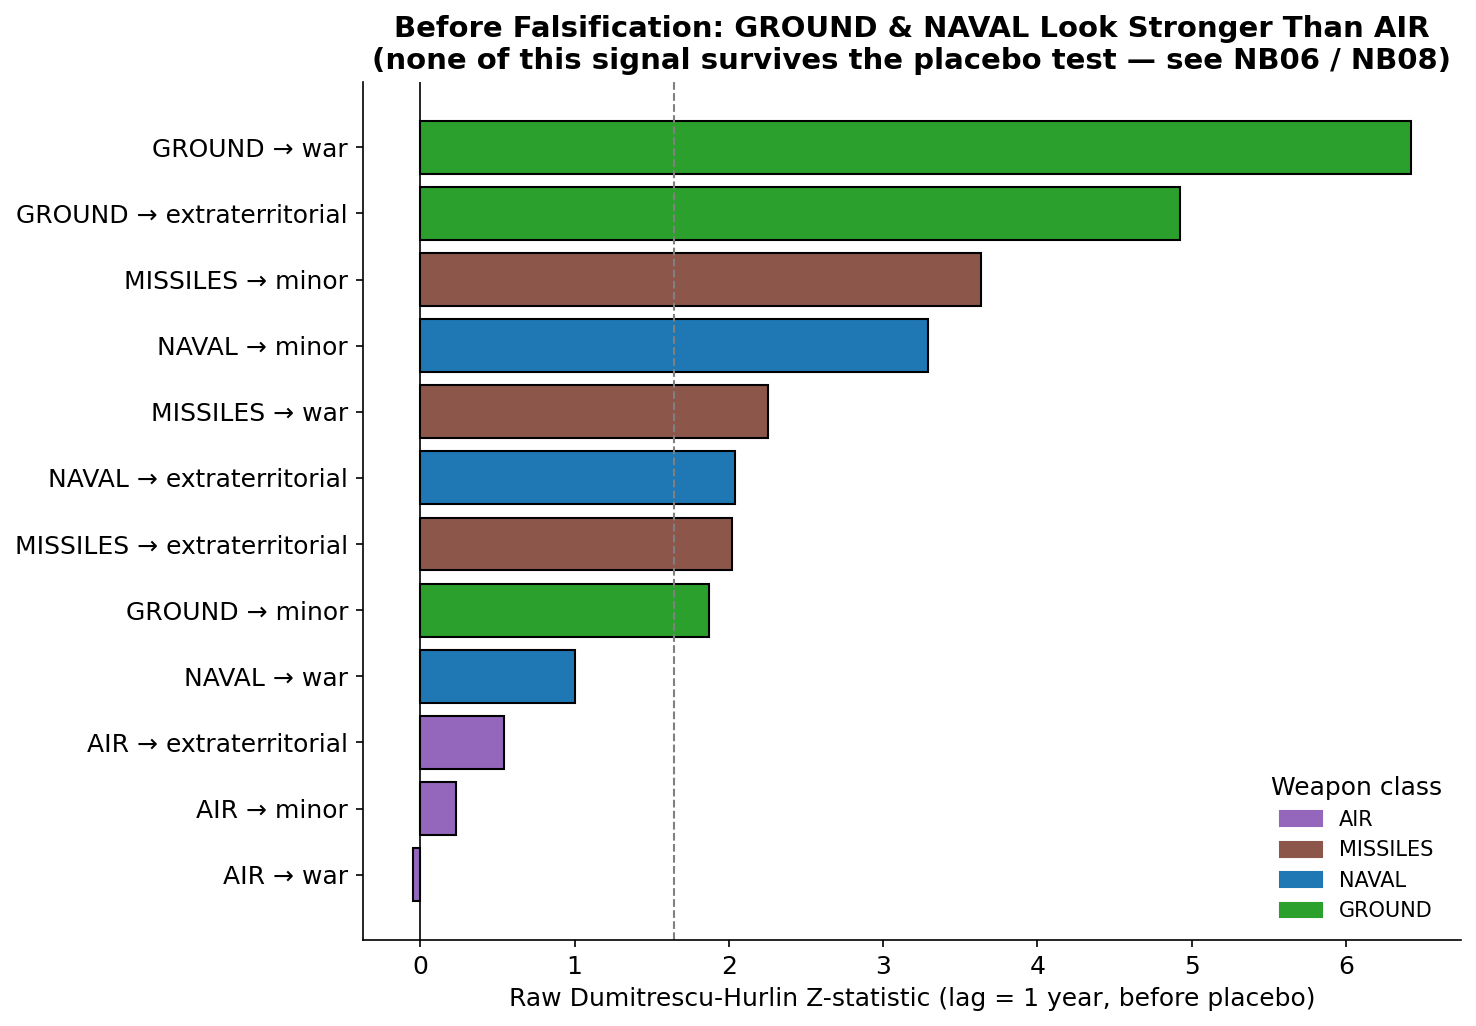

Fig 4 saved.

Largest raw |Z| at lag=1 belongs to: GROUND — not AIR, the class the Drone Effect hypothesis is built around.


In [9]:
# ── 3.3 Before falsification: the "wrong" weapon classes look strongest ──────
lag1_dh = dh_df[dh_df["lag"] == 1].copy()
lag1_dh["abs_Z"] = lag1_dh["Z"].abs()
lag1_dh = lag1_dh.sort_values("Z")
lag1_dh["label"] = lag1_dh["weapon"] + " \u2192 " + lag1_dh["outcome"].str.replace("part_n_", "", regex=False)

weapon_palette = {"AIR": "#9467bd", "MISSILES": "#8c564b", "NAVAL": "#1f77b4", "GROUND": "#2ca02c"}
colors = [weapon_palette.get(w, "gray") for w in lag1_dh["weapon"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(lag1_dh["label"], lag1_dh["Z"], color=colors, edgecolor="black")
ax.axvline(0, color="black", lw=0.8)
ax.axvline(1.645, color="gray", linestyle="--", lw=1, label="Z = 1.645 (p = 0.05)")
ax.set_xlabel("Raw Dumitrescu-Hurlin Z-statistic (lag = 1 year, before placebo)")
ax.set_title("Before Falsification: GROUND & NAVAL Look Stronger Than AIR\n"
              "(none of this signal survives the placebo test \u2014 see NB06 / NB08)")
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=c, label=w) for w, c in weapon_palette.items()]
ax.legend(handles=handles, loc="lower right", frameon=False, title="Weapon class")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_raw_signal_inversion.png", dpi=300, bbox_inches="tight")
plt.show()
print("Fig 4 saved.")

top_weapon = lag1_dh.loc[lag1_dh["abs_Z"].idxmax(), "weapon"]
print(f"\nLargest raw |Z| at lag=1 belongs to: {top_weapon} "
      f"\u2014 not AIR, the class the Drone Effect hypothesis is built around.")

The Drone Effect hypothesis predicted AIR and MISSILES — precision-strike,
lower-collateral capability classes — would show the cleanest lead-lag signal toward
low-intensity conflict. Instead, GROUND and NAVAL (older, blunter capability classes)
produce the largest raw Z-statistics. The honest caveat matters more than the
curiosity: **none of this survives placebo falsification** (NB06, NB08), so this is
not a competing finding to chase — it's a reminder that raw significance, before any
falsification test, can point in exactly the wrong direction from where the genuine
signal (or lack of one) actually is.

## Section 4 — Closing Synthesis

None of the findings in this notebook were the point of the project when it started.
They emerged from building the pipeline carefully enough to catch its own mistakes,
running every major result through more than one robustness lens, and paying
attention when a "boring" check (a subperiod split, a count-model comparison, a
bootstrap loop) produced something unexpected.

That's worth saying directly to a lecturer: a research project that only reports
clean confirmation of its original hypotheses is usually a project that didn't look
very hard. This one looked hard enough to find a real measurement bug in its own
arms-transfer data, a coalition-attribution error in a 20-year-old conflict dataset,
and a stronger finding than the one it set out to test — and was able to say so
clearly because every one of those discoveries is traceable to a specific notebook,
a specific cell, and a specific saved table.

## Section 5 — Outputs

In [10]:
print(f"Bug catalog        -> {TBL_DIR / 'bug_catalog.csv'}")
print(f"Robustness table   -> {TBL_DIR / 'cross_method_robustness.csv'}")
print(f"All new figures    -> {FIG_DIR}/")
print()
for f in sorted(FIG_DIR.glob("*.png")):
    print(f"  {f.name}")

print()
print("=" * 70)
print("NB-09 COMPLETE")
print("=" * 70)

Bug catalog        -> D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\tables\nb09\bug_catalog.csv
Robustness table   -> D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\tables\nb09\cross_method_robustness.csv
All new figures    -> D:\post graduate\assignments and projects\sem 3\BDA\PeaceMakers' Arms Race\version 2\figures\nb09/

  fig1_stability_vs_validity.png
  fig2_battle_death_intensity.png
  fig3_era_reversal.png
  fig4_raw_signal_inversion.png

NB-09 COMPLETE
